In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('world_air_quality_with_locations.csv')
df.head(5)

,Unnamed: 0,Country Code,City,Location,Coordinates,Pollutant,Source Name,Unit,Value,Last Updated,Country Label,Lat,Long
0,0,CL,Catemu,Santa Margarita,"-32.776573, -70.938144",PM2.5,Chile - SINCA,µg/m³,0.00,2017-06-28T17:00:00+04:00,Chile,-32.776573,-70.938144
1,1,CL,Coyhaique,Coyhaique II,"-45.579045667164, -72.049964505825",SO2,Chile - SINCA,µg/m³,16.63,2023-08-09T11:00:00+04:00,Chile,-45.579046,-72.049965
2,2,CL,Calama,Colegio Pedro Vergara Keller,"-22.44283906304, -68.932546346863",PM10,Chile - SINCA,µg/m³,69.00,2023-08-09T11:00:00+04:00,Chile,-22.442839,-68.932546
3,3,CL,Coquimbo,La Serena,"-29.933006518748, -71.261966365967",PM2.5,Chile - SINCA,µg/m³,21.00,2023-08-09T11:00:00+04:00,Chile,-29.933007,-71.261966
4,4,CL,Talagante,Talagante,"-33.673752071375, -70.953064737434",NO2,Chile - SINCA,µg/m³,134.80,2019-12-05T21:00:00+04:00,Chile,-33.673752,-70.953065


In [3]:
df.shape


(43450, 13)

In [4]:
df.columns

Index(['Unnamed: 0', 'Country Code', 'City', 'Location', 'Coordinates',
       'Pollutant', 'Source Name', 'Unit', 'Value', 'Last Updated',
       'Country Label', 'Lat', 'Long'],
      dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43450 entries, 0 to 43449
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     43450 non-null  int64  
 1   Country Code   43450 non-null  object 
 2   City           26744 non-null  object 
 3   Location       43448 non-null  object 
 4   Coordinates    43231 non-null  object 
 5   Pollutant      43450 non-null  object 
 6   Source Name    43450 non-null  object 
 7   Unit           43450 non-null  object 
 8   Value          43450 non-null  float64
 9   Last Updated   43450 non-null  object 
 10  Country Label  43335 non-null  object 
 11  Lat            43231 non-null  float64
 12  Long           43231 non-null  float64
dtypes: float64(3), int64(1), object(9)
memory usage: 4.3+ MB


In [6]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [7]:
df.isnull().sum()

Country Code         0
City             16706
Location             2
Coordinates        219
Pollutant            0
Source Name          0
Unit                 0
Value                0
Last Updated         0
Country Label      115
Lat                219
Long               219
dtype: int64

In [8]:
df['Last Updated']=pd.to_datetime(df['Last Updated'])

In [9]:
df.columns= df.columns.str.lower().str.replace(' ','_')

In [10]:
df.columns

Index(['country_code', 'city', 'location', 'coordinates', 'pollutant',
       'source_name', 'unit', 'value', 'last_updated', 'country_label', 'lat',
       'long'],
      dtype='object')

In [11]:
df.fillna(0,inplace=True)

In [12]:
df.describe()

,value,lat,long
count,4.345000e+04,43450.000000,43450.000000
mean,7.655028e+02,32.581830,26.375797
std,3.270964e+04,20.180000,77.808945
min,-4.905140e+04,-74.166278,-161.767000
25%,1.900000e+00,27.554793,-2.749527
50%,1.060000e+01,37.748600,19.783933
75%,3.500000e+01,44.815142,105.669800
max,3.198676e+06,78.906690,172.681343


In [14]:
df['pollutant'].value_counts()

pollutant
PM2.5    7846
O3       7748
NO2      7613
PM10     7225
SO2      5759
CO       4570
NO       2020
NOX       565
BC        100
PM1         4
Name: count, dtype: int64

In [15]:
df['country_label'].value_counts().head(10)

country_label
China            11112
United States     6051
India             2364
Spain             2307
Germany           1891
France            1844
Turkey            1694
South Africa      1641
Thailand          1582
Italy             1535
Name: count, dtype: int64

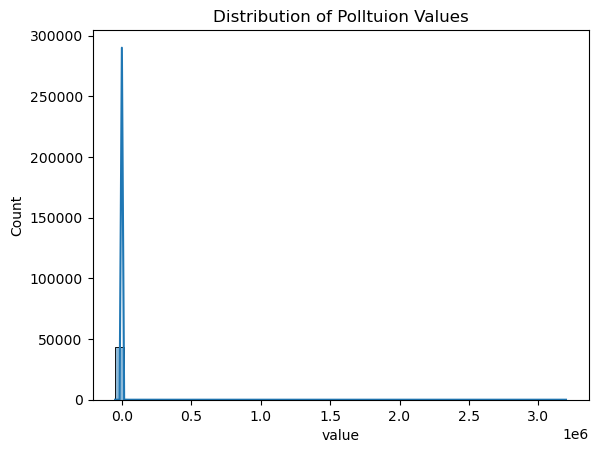

In [24]:
sns.histplot(data= df['value'],kde=True,bins=50)
plt.title("Distribution of Polltuion Values")
plt.show()

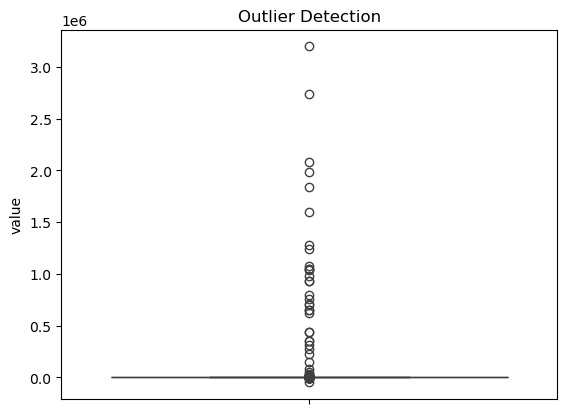

In [9]:
sns.boxplot(data=df['value'])
plt.title("Outlier Detection")
plt.show()

In [16]:
df=df[df['value']>=0]

In [17]:
q1= df['value'].quantile(0.25)
q3= df['value'].quantile(0.75)
IQR= q3-q1

lower_bound= q1 - 1.5*IQR
upper_bound= q3 + 1.5*IQR

df= df[(df['value']>=lower_bound)&(df['value']<=upper_bound)]


In [19]:
df.describe()

,value,lat,long
count,37033.000000,37033.000000,37033.000000
mean,14.907217,32.510015,18.735349
std,18.482127,20.920193,78.262935
min,0.000000,-74.166278,-161.767000
25%,1.000000,26.766433,-6.570420
50%,8.000000,38.299100,15.656191
75%,21.000000,45.440340,100.536501
max,86.299450,78.906690,172.681343


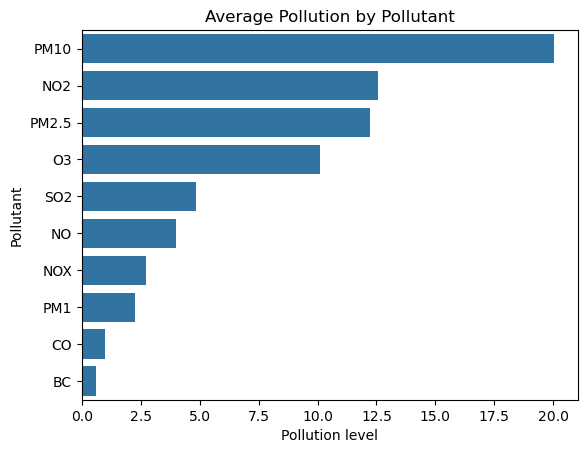

In [21]:
pollutant_avg= df.groupby('pollutant')['value'].mean().sort_values(ascending=False)

sns.barplot(x=pollutant_avg,y=pollutant_avg.index)
plt.title("Average Pollution by Pollutant")
plt.xlabel("Pollution level")
plt.ylabel("Pollutant")
plt.show()

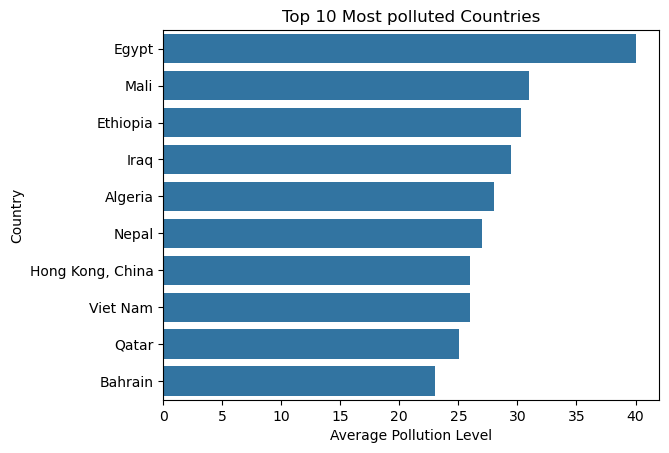

In [22]:
country_avg= df.groupby('country_label')['value'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=country_avg,y=country_avg.index)
plt.title("Top 10 Most polluted Countries")
plt.xlabel("Average Pollution Level")
plt.ylabel("Country")
plt.show()

In [21]:
df['year']= df['last_updated'].dt.year

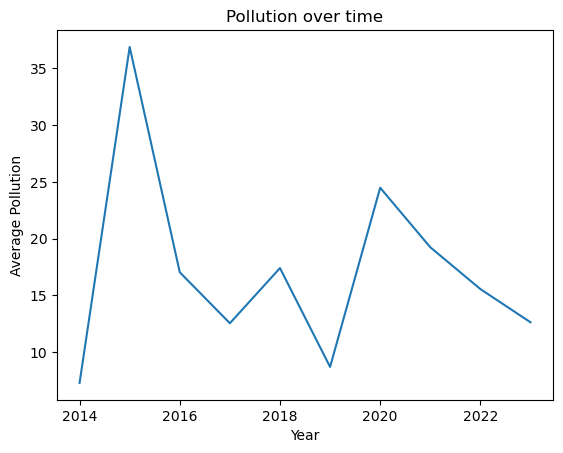

In [23]:
yearly_trend= df.groupby('year')['value'].mean()
sns.lineplot(x=yearly_trend.index,y=yearly_trend)
plt.title('Pollution over time')
plt.xlabel('Year')
plt.ylabel('Average Pollution')
plt.show()

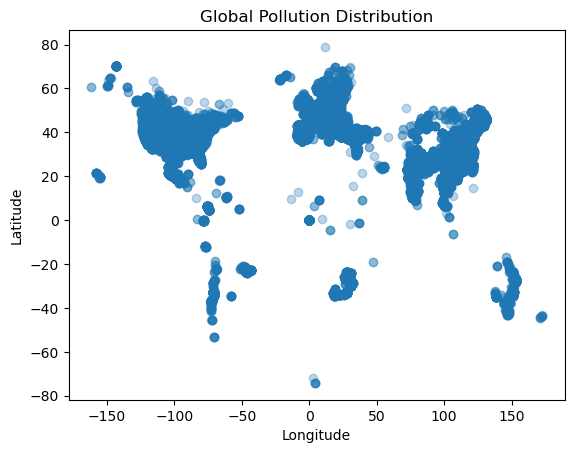

In [25]:
plt.scatter(df['long'],df['lat'],alpha=0.3)
plt.title('Global Pollution Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()